<div style="background-color: #f8f9fa; padding: 20px; border-radius: 10px; box-shadow: 0 4px 6px rgba(0, 0, 0, 0.1);">
  <div style="display: flex; justify-content: space-between; align-items: center;">
    <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal Logo" width="250" height="auto">
    <div style="text-align: right;">
      <h1 style="color: #007bff; margin: 0; font-size: 24px;">Coordenadas Homogêneas e Transformações Afins</h1>
    </div>
  </div>
  <hr style="border: none; height: 1px; background-color: #007bff; margin: 20px 0;">
  <p style="color: #6c757d; margin: 5px 0 0; font-size: 14px;"><strong>Autor:</strong> Carlos Melo | <a href="https://sigmoidal.ai">sigmoidal.ai</a></p>
</div>

# Coordenadas Homogêneas e Transformações Afins

Neste notebook, implementamos as transformações geométricas afins (scaling, rotação, translação e cisalhamento) usando coordenadas homogêneas e matrizes 3x3.

A implementação é feita do zero, sem bibliotecas de visão computacional, para que cada etapa da transformação fique explícita:

- Construção manual de cada matriz de transformação
- Mapeamento inverso para gerar a imagem transformada
- Interpolação por vizinho mais próximo e bilinear
- Composição de múltiplas transformações em uma única matriz

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Imagem Sintética de Teste

Criamos uma grade regular como imagem de teste. A grade facilita a visualização das deformações causadas por cada transformação.

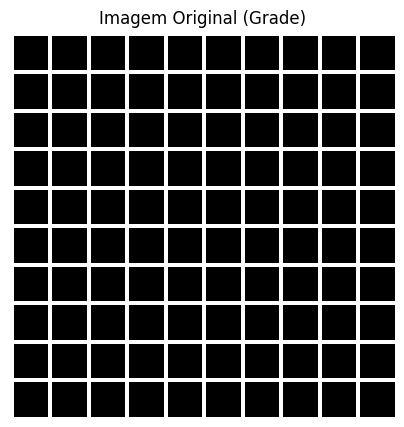

In [2]:
def criar_grade(tamanho=100, espacamento=10):
    """Cria uma imagem binaria com grade regular."""
    img = np.zeros((tamanho, tamanho), dtype=np.float32)
    img[::espacamento, :] = 255
    img[:, ::espacamento] = 255
    return img

original = criar_grade(100, 10)

plt.figure(figsize=(5, 5))
plt.imshow(original, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem Original (Grade)')
plt.axis('off')
plt.show()

## Interpolação de Intensidade

Quando aplicamos uma transformação geométrica, os pixels da imagem de saída podem corresponder a coordenadas não inteiras na imagem original. Precisamos de um método para estimar a intensidade nessas coordenadas fracionárias.

Implementamos dois métodos:

- **Vizinho mais próximo**: arredonda para o pixel inteiro mais próximo. Rápido, mas produz bordas serrilhadas.
- **Bilinear**: pondera os 4 vizinhos mais próximos. Produz transições suaves.

In [3]:
def interpolacao_vizinho(imagem, v, w):
    """Interpolacao por vizinho mais proximo."""
    h, w_img = imagem.shape
    v_round = int(np.round(v))
    w_round = int(np.round(w))
    if 0 <= v_round < w_img and 0 <= w_round < h:
        return imagem[w_round, v_round]
    return 0.0


def interpolacao_bilinear(imagem, v, w):
    """Interpolacao bilinear usando os 4 vizinhos mais proximos."""
    h, w_img = imagem.shape
    v_floor, w_floor = int(np.floor(v)), int(np.floor(w))
    v_ceil, w_ceil = v_floor + 1, w_floor + 1

    if v_ceil >= w_img or w_ceil >= h or v_floor < 0 or w_floor < 0:
        return 0.0

    # 4 vizinhos
    a = imagem[w_floor, v_floor]
    b = imagem[w_floor, v_ceil]
    c = imagem[w_ceil, v_floor]
    d = imagem[w_ceil, v_ceil]

    # Pesos fracionarios
    dv = v - v_floor
    dw = w - w_floor

    # Formula bilinear
    topo = a * (1 - dv) + b * dv
    base = c * (1 - dv) + d * dv
    return topo * (1 - dw) + base * dw

## Aplicando Transformações Afins com Mapeamento Inverso

Para cada pixel $(x, y)$ da imagem de saída, calculamos a coordenada correspondente na imagem original usando a inversa da matriz de transformação:

$$(v, w) = T^{-1} \cdot (x, y, 1)$$

Isso garante que todo pixel da saída receba um valor, evitando buracos na imagem.

In [4]:
def aplicar_transformacao(imagem, T, interpolacao='bilinear'):
    """Aplica transformacao afim usando mapeamento inverso."""
    h, w = imagem.shape
    saida = np.zeros((h, w), dtype=np.float32)
    T_inv = np.linalg.inv(T)

    for y in range(h):
        for x in range(w):
            coord_saida = np.array([x, y, 1])
            coord_entrada = T_inv @ coord_saida
            v, w_orig = coord_entrada[0], coord_entrada[1]

            if interpolacao == 'vizinho':
                saida[y, x] = interpolacao_vizinho(imagem, v, w_orig)
            else:
                saida[y, x] = interpolacao_bilinear(imagem, v, w_orig)

    return saida

## Transformação Identidade

A matriz identidade não altera a imagem. Serve como verificação de que a implementação está correta.

$$
I = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

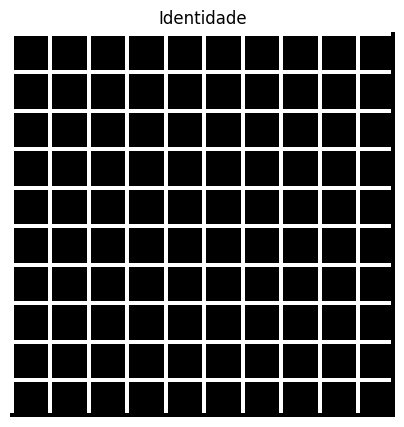

In [5]:
T_identidade = np.array([[1, 0, 0],
                         [0, 1, 0],
                         [0, 0, 1]], dtype=np.float64)

resultado = aplicar_transformacao(original, T_identidade)

plt.figure(figsize=(5, 5))
plt.imshow(resultado, cmap='gray', vmin=0, vmax=255)
plt.title('Identidade')
plt.axis('off')
plt.show()

## Scaling (Escala)

$$
T_{escala} = \begin{bmatrix} S_x & 0 & 0 \\ 0 & S_y & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

Com $S_x = 1.5$ e $S_y = 0.5$, a imagem é expandida horizontalmente e comprimida verticalmente.

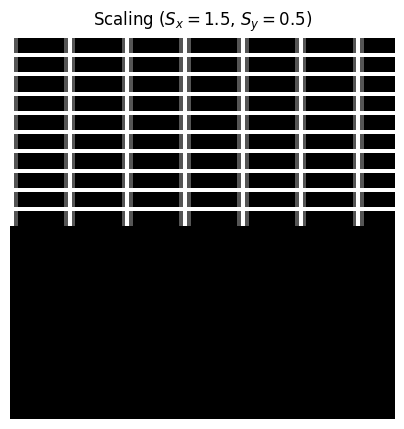

In [6]:
cx, cy = 1.5, 0.5
T_escala = np.array([[cx, 0, 0],
                     [0, cy, 0],
                     [0,  0, 1]], dtype=np.float64)

resultado = aplicar_transformacao(original, T_escala)

plt.figure(figsize=(5, 5))
plt.imshow(resultado, cmap='gray', vmin=0, vmax=255)
plt.title('Scaling ($S_x=1.5$, $S_y=0.5$)')
plt.axis('off')
plt.show()

## Rotação

$$
T_{rotacao} = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

A rotação ocorre em torno da origem (canto superior esquerdo). Note como parte da imagem sai do campo de visão.

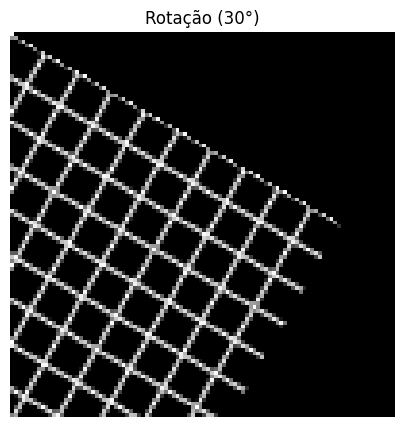

In [7]:
theta = np.deg2rad(30)
c, s = np.cos(theta), np.sin(theta)
T_rotacao = np.array([[c, -s, 0],
                      [s,  c, 0],
                      [0,  0, 1]], dtype=np.float64)

resultado = aplicar_transformacao(original, T_rotacao)

plt.figure(figsize=(5, 5))
plt.imshow(resultado, cmap='gray', vmin=0, vmax=255)
plt.title('Rotação (30°)')
plt.axis('off')
plt.show()

## Translação

$$
T_{translacao} = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \\ 0 & 0 & 1 \end{bmatrix}
$$

Desloca a imagem inteira sem alterar sua forma. A translação é justamente a operação que matrizes 2x2 não conseguem representar.

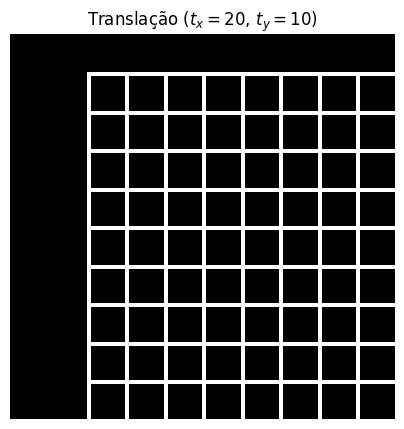

In [8]:
tx, ty = 20, 10
T_translacao = np.array([[1, 0, tx],
                         [0, 1, ty],
                         [0, 0,  1]], dtype=np.float64)

resultado = aplicar_transformacao(original, T_translacao)

plt.figure(figsize=(5, 5))
plt.imshow(resultado, cmap='gray', vmin=0, vmax=255)
plt.title('Translação ($t_x=20$, $t_y=10$)')
plt.axis('off')
plt.show()

## Cisalhamento Horizontal (Shear)

$$
T_{shear_h} = \begin{bmatrix} 1 & s_h & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

Desloca cada linha horizontalmente de forma proporcional à sua posição vertical. Transforma retângulos em paralelogramos.

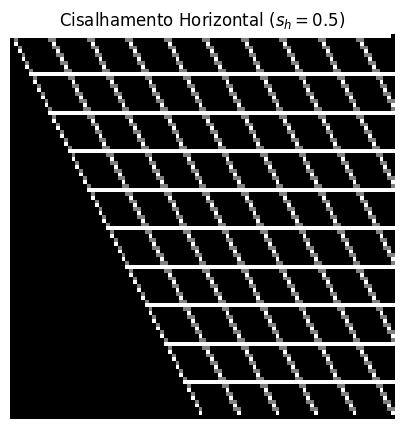

In [9]:
sh = 0.5
T_shear_h = np.array([[1, sh, 0],
                      [0,  1, 0],
                      [0,  0, 1]], dtype=np.float64)

resultado = aplicar_transformacao(original, T_shear_h)

plt.figure(figsize=(5, 5))
plt.imshow(resultado, cmap="gray", vmin=0, vmax=255)
plt.title('Cisalhamento Horizontal ($s_h=0.5$)')
plt.axis('off')
plt.show()

## Cisalhamento Vertical

$$
T_{shear_v} = \begin{bmatrix} 1 & 0 & 0 \\ s_v & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

Desloca cada coluna verticalmente de forma proporcional à sua posição horizontal.

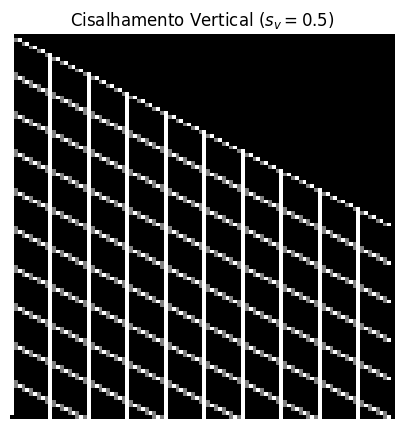

In [10]:
sv = 0.5
T_shear_v = np.array([[1,  0, 0],
                      [sv, 1, 0],
                      [0,  0, 1]], dtype=np.float64)

resultado = aplicar_transformacao(original, T_shear_v)

plt.figure(figsize=(5, 5))
plt.imshow(resultado, cmap="gray", vmin=0, vmax=255)
plt.title('Cisalhamento Vertical ($s_v=0.5$)')
plt.axis('off')
plt.show()

## Composição de Transformações

A grande vantagem das coordenadas homogêneas é poder compor múltiplas transformações em uma única multiplicação matricial:

$$T_{composta} = T_{rotacao} \cdot T_{escala}$$

Primeiro aplica o scaling, depois a rotação. A ordem importa, pois a multiplicação de matrizes não é comutativa.

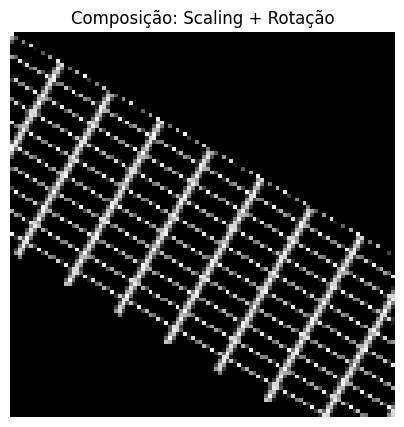

In [11]:
T_composta = T_rotacao @ T_escala

resultado = aplicar_transformacao(original, T_composta)

plt.figure(figsize=(5, 5))
plt.imshow(resultado, cmap='gray', vmin=0, vmax=255)
plt.title('Composição: Scaling + Rotação')
plt.axis('off')
plt.show()

## Rotação em Torno do Centro da Imagem

A rotação padrão gira em torno da origem (0, 0). Para girar em torno do centro da imagem, compomos três transformações:

1. Transladar o centro para a origem
2. Rotacionar
3. Transladar de volta

$$T = T_{+centro} \cdot T_{rotacao} \cdot T_{-centro}$$

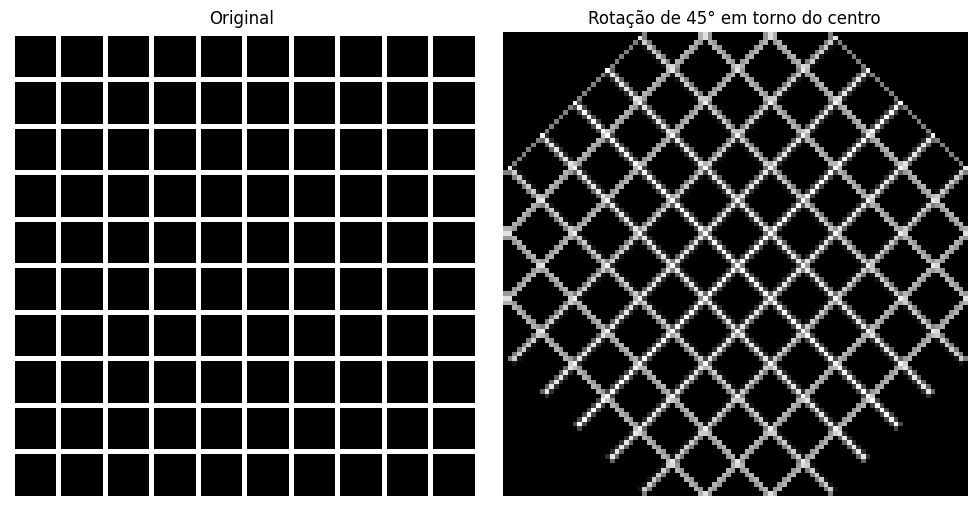

In [12]:
h, w = original.shape
cx_img, cy_img = w / 2, h / 2

# Transladar centro para a origem
T_para_origem = np.array([[1, 0, -cx_img],
                          [0, 1, -cy_img],
                          [0, 0,       1]], dtype=np.float64)

# Transladar de volta
T_de_volta = np.array([[1, 0, cx_img],
                       [0, 1, cy_img],
                       [0, 0,     1]], dtype=np.float64)

# Rotacao de 45 graus
theta = np.deg2rad(45)
c, s = np.cos(theta), np.sin(theta)
T_rot = np.array([[c, -s, 0],
                  [s,  c, 0],
                  [0,  0, 1]], dtype=np.float64)

# Composicao
T_rot_centro = T_de_volta @ T_rot @ T_para_origem

resultado = aplicar_transformacao(original, T_rot_centro)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(original, cmap='gray', vmin=0, vmax=255)
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(resultado, cmap='gray', vmin=0, vmax=255)
axs[1].set_title('Rotação de 45° em torno do centro')
axs[1].axis('off')
plt.tight_layout()
plt.show()

## Comparação de Interpolações

A escolha do método de interpolação afeta diretamente a qualidade visual da imagem transformada. Comparamos vizinho mais próximo (bordas serrilhadas) e bilinear (transições suaves) usando uma imagem da letra T.

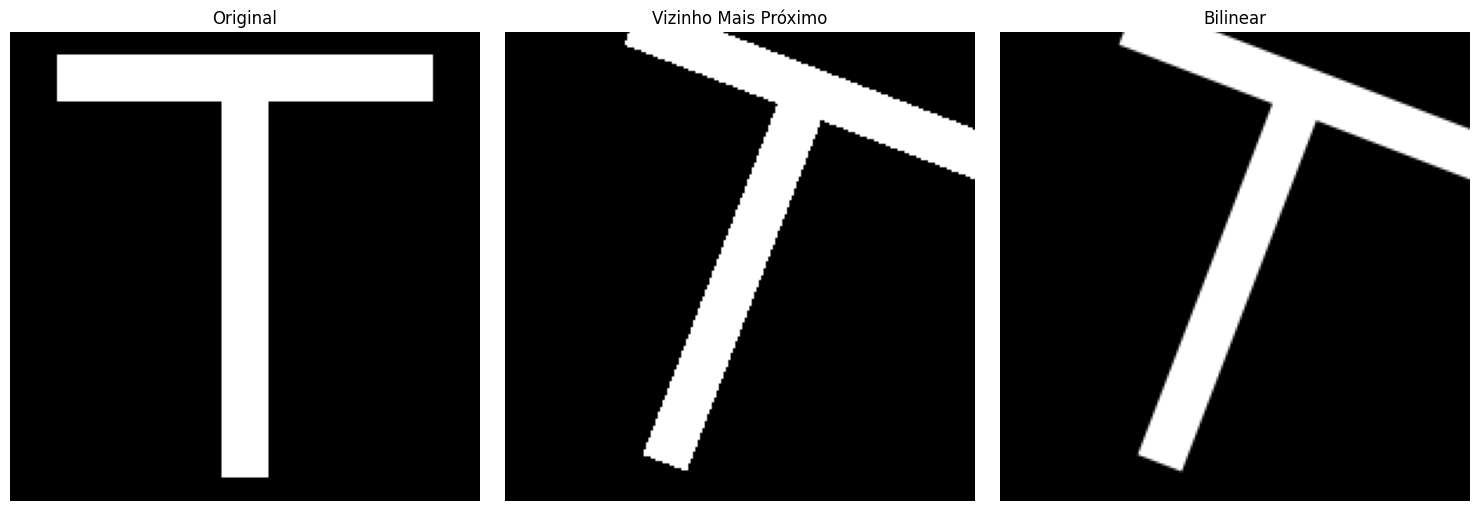

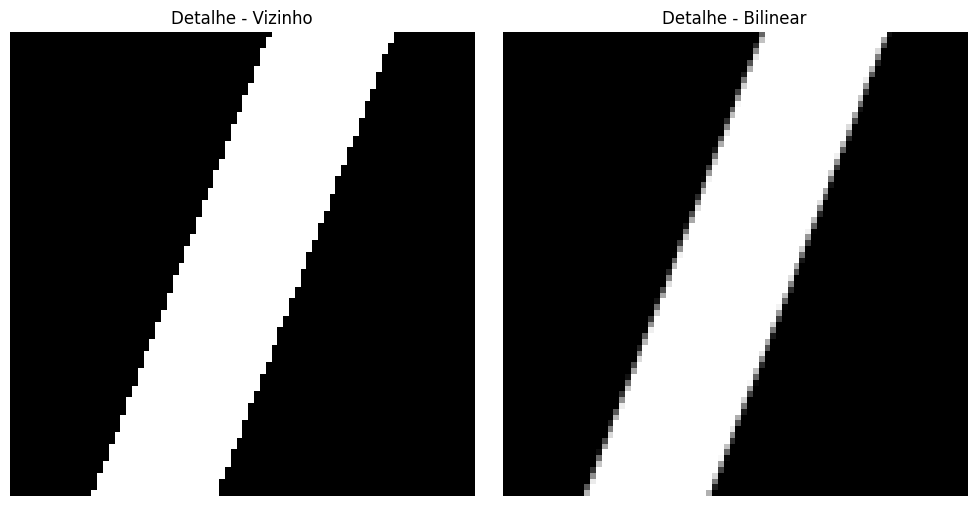

In [13]:
def criar_letra_t(tamanho=100, espessura=10):
    """Cria imagem binaria da letra T."""
    img = np.zeros((tamanho, tamanho), dtype=np.float32)
    # Barra horizontal
    img[10:10+espessura, 20:tamanho-20] = 255
    # Barra vertical
    img[10:tamanho-10, tamanho//2 - espessura//2:tamanho//2 + espessura//2] = 255
    return img

letra_t = criar_letra_t(200, 20)

# Rotacao de 21 graus em torno do centro
h, w = letra_t.shape
cx_img, cy_img = w / 2, h / 2

T_para_origem = np.array([[1, 0, -cx_img],
                          [0, 1, -cy_img],
                          [0, 0,       1]], dtype=np.float64)

T_de_volta = np.array([[1, 0, cx_img],
                       [0, 1, cy_img],
                       [0, 0,     1]], dtype=np.float64)

theta = np.deg2rad(21)
c, s = np.cos(theta), np.sin(theta)
T_rot = np.array([[c, -s, 0],
                  [s,  c, 0],
                  [0,  0, 1]], dtype=np.float64)

T_rot_centro = T_de_volta @ T_rot @ T_para_origem

# Aplicar com cada interpolacao
rot_vizinho = aplicar_transformacao(letra_t, T_rot_centro, interpolacao='vizinho')
rot_bilinear = aplicar_transformacao(letra_t, T_rot_centro, interpolacao='bilinear')

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(letra_t, cmap='gray', vmin=0, vmax=255)
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(rot_vizinho, cmap='gray', vmin=0, vmax=255)
axs[1].set_title('Vizinho Mais Próximo')
axs[1].axis('off')
axs[2].imshow(rot_bilinear, cmap='gray', vmin=0, vmax=255)
axs[2].set_title('Bilinear')
axs[2].axis('off')
plt.tight_layout()
plt.show()

# Detalhe ampliado das bordas
recorte = (slice(60, 140), slice(60, 140))
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(rot_vizinho[recorte], cmap='gray', vmin=0, vmax=255)
axs[0].set_title('Detalhe - Vizinho')
axs[0].axis('off')
axs[1].imshow(rot_bilinear[recorte], cmap='gray', vmin=0, vmax=255)
axs[1].set_title('Detalhe - Bilinear')
axs[1].axis('off')
plt.tight_layout()
plt.show()